# FakeOut

## EDA

In [147]:
import pandas as pd
import numpy as np

## Loading Our Data

In [115]:
# Load the data
df = pd.read_csv("apartments_for_rent_classified_100K.csv", encoding='latin-1', on_bad_lines='skip', delimiter=';')

# Set display options to show all columns and adjust width
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

/var/folders/kv/s43skrtj28xgrn72fc1vv5lw0000gn/T/ipykernel_27316/3502588502.py:2: DtypeWarning: Columns (0: address) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("apartments_for_rent_classified_100K.csv", encoding='latin-1', on_bad_lines='skip', delimiter=';')


### Whats in the data?

In [116]:
print(df.shape)
df.head()


(99492, 22)


,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,"$2,195",Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,"$1,250",Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,NaN,1395.0,"$1,395",Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1600.0,"$1,600",Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1577360330
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",975.0,$975,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1577360308


In [117]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             99492 non-null  int64  
 1   category       99492 non-null  str    
 2   title          99492 non-null  str    
 3   body           99492 non-null  str    
 4   amenities      83448 non-null  str    
 5   bathrooms      99429 non-null  float64
 6   bedrooms       99368 non-null  float64
 7   currency       99492 non-null  str    
 8   fee            99492 non-null  str    
 9   has_photo      99492 non-null  str    
 10  pets_allowed   39068 non-null  str    
 11  price          99491 non-null  float64
 12  price_display  99491 non-null  str    
 13  price_type     99492 non-null  str    
 14  square_feet    99492 non-null  int64  
 15  address        7943 non-null   str    
 16  cityname       99190 non-null  str    
 17  state          99190 non-null  str    
 18  latitude       99

- There are approximately 39K rows that have non-null 'pets_allowed' value but we feel that is not a crucial category and would not cause much harm in not having a value.

- On the other hand, the feature 'Address' has 7943 non-null values, but 'latitude' and 'longitude' make up for it. So it should not be much of an issue.

- We decided to not drop any non-null values since they might be useful in the future for fake listings prediction. But, 'price_display' and 'price' show the exact same information, but 'price' is numerical and is therefore easy to work with, so we will be dropping 'price_display'.

In [118]:
df.drop(columns=['price_display'], inplace=True)
df.head(1)

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.852,-118.3759,RentLingo,1577360355


### What are the categories?

In [119]:
# show different categories of the dataset
print(df['category'].value_counts())

category
housing/rent/apartment            99431
housing/rent/commercial/retail       42
housing/rent                          7
housing/rent/home                     4
housing/rent/short_term               4
housing/rent/condo                    3
housing/rent/other                    1
Name: count, dtype: int64


### Observations
We have a few different categories lets see how different they are

In [120]:
df_rentapt = df[df['category'] == 'housing/rent/apartment']
df_rentapt.head(5)

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668640009,housing/rent/apartment,One BR 507 & 509 Esplanade,"This unit is located at 507 & 509 Esplanade, R...",NaN,1.0,1.0,USD,No,Thumbnail,Cats,2195.0,Monthly,542,507 509 Esplanade,Redondo Beach,CA,33.8520,-118.3759,RentLingo,1577360355
1,5668639818,housing/rent/apartment,Three BR 146 Lochview Drive,"This unit is located at 146 Lochview Drive, Ne...",NaN,1.5,3.0,USD,No,Thumbnail,"Cats,Dogs",1250.0,Monthly,1500,146 Lochview Dr,Newport News,VA,37.0867,-76.4941,RentLingo,1577360340
2,5668639686,housing/rent/apartment,Three BR 3101 Morningside Drive,This unit is located at 3101 Morningside Drive...,NaN,2.0,3.0,USD,No,Thumbnail,NaN,1395.0,Monthly,1650,3101 Morningside Dr,Raleigh,NC,35.8230,-78.6438,RentLingo,1577360332
3,5668639659,housing/rent/apartment,Two BR 209 Aegean Way,"This unit is located at 209 Aegean Way, Vacavi...",NaN,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1600.0,Monthly,820,209 Aegean Way,Vacaville,CA,38.3622,-121.9712,RentLingo,1577360330
4,5668639374,housing/rent/apartment,One BR 4805 Marquette NE,"This unit is located at 4805 Marquette NE, Alb...",NaN,1.0,1.0,USD,No,Thumbnail,"Cats,Dogs",975.0,Monthly,624,4805 Marquette NE,Albuquerque,NM,35.1038,-106.6110,RentLingo,1577360308


This is our biggest subset of categories.

In [121]:
# print category housing/rent/home
df_renthome = df[df['category'] == 'housing/rent/home']
df_renthome

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
6394,5663111837,housing/rent/home,"622 North Wayne Street, Apartment. A",Milledgeville STUCCO SIDING - DOWNTOWN WAYNE S...,"AC,Cable or Satellite,Dishwasher,Internet Acce...",1.0,2.0,USD,No,Thumbnail,NaN,625.0,Monthly,828,622 North Wayne St,Milledgeville,GA,33.0769,-83.3032,ListedBuy,1576878211
6395,5663106093,housing/rent/home,"1350 Irwinton Road, Apartment. B",Milledgeville SWINT AVENUE/441 SOUTH  VINYL S...,"AC,Cable or Satellite,Internet Access,Patio/De...",1.0,1.0,USD,No,Thumbnail,NaN,475.0,Monthly,664,1350 Irwinton Rd,Milledgeville,GA,33.0769,-83.3032,ListedBuy,1576877678
50971,5411277752,housing/rent/home,"529 S 10th St Apartment 2 San Jose, CA 95112",San Jose three Beds/two Baths Apartment in Dow...,"AC,Cable or Satellite,Dishwasher,Fireplace,Gar...",2.0,3.0,USD,No,Thumbnail,"Cats,Dogs",2000.0,Monthly,942,NaN,San Jose,CA,37.3108,-121.8645,ListedBuy,1562423091
50986,5411274086,housing/rent/home,Renovated Two BR Duplex Home for Rent on James...,"Move into this gorgeous, completely up-to-date...",Washer Dryer,1.0,2.0,USD,No,Thumbnail,"Cats,Dogs",1450.0,Monthly,950,NaN,Charleston,SC,32.8113,-79.9947,ListedBuy,1562422872


This looks very similar to the apartments subset.

In [122]:
df_rent = df[df['category'] == 'housing/rent']
df_rent

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
11930,5508873595,housing/rent,Newport News - Well maintained Two BR home wit...,Enclosed backyard and more. Centrally Located ...,Parking,1.5,2.0,USD,No,Yes,NaN,1250.0,Monthly,1137,NaN,Newport News,VA,37.1451,-76.5397,RentDigs.com,1568758737
57230,5197883238,housing/rent,Lovely 5 BR and a Loft home in desirable Cresl...,"1 beds and full size bathroom, downstairs. Lar...","Fireplace,Parking,Patio/Deck,Wood Floors",3.0,5.0,USD,No,Thumbnail,NaN,2695.0,Monthly,2914,NaN,Elk Grove,CA,38.4070,-121.3752,RentDigs.com,1550826861
62646,5198222557,housing/rent,Beautiful Three BR Two BA home with a bonus lo...,"Park, shopping, restaurants, interstate access...","Patio/Deck,Washer Dryer",2.0,3.0,USD,No,Yes,NaN,1300.0,Monthly,1580,NaN,Lexington,KY,38.0983,-84.4932,RentDigs.com,1550841933
68844,5198404371,housing/rent,Contemporary ranch style home with Three BR & ...,Large sunroom & wrap around deck over looking ...,"Fireplace,Patio/Deck,Wood Floors",2.0,3.0,USD,No,Thumbnail,NaN,1595.0,Monthly,2043,NaN,Newport News,VA,36.8961,-76.2550,RentDigs.com,1550849465
75995,5197797656,housing/rent,"Excellent home with 2 bdrooms, loft, and 1 BA....","Every room has a ceiling fan in it, along with...","Alarm,Fireplace,Refrigerator",1.0,3.0,USD,No,Yes,"Cats,Dogs",800.0,Monthly,2500,NaN,Kansas City,MO,39.0342,-94.5429,RentDigs.com,1550821168
91265,5122165581,housing/rent,"Pittsburg Three BR plus loft, 2. Five BA Home - .",This home is walkable distance to Bart station...,NaN,2.5,3.0,USD,No,Yes,NaN,2695.0,Monthly,2026,NaN,Pittsburg,CA,38.0159,-121.9111,RentDigs.com,1544263338
92570,5121297015,housing/rent,Welcome home to the most desired loft style li...,"This beautiful home has oversized windows, ele...","AC,Dishwasher,Gym,Patio/Deck,Refrigerator,Wash...",1.0,1.0,USD,No,Yes,"Cats,Dogs",3700.0,Monthly,700,NaN,Brooklyn,NY,40.6496,-73.9596,RentDigs.com,1544191798


Again it looks very similar to the two previous categories.

In [123]:
df_comercial = df[df['category'] == 'housing/rent/commercial/retail']
##df_comercial.head(5)
df_comercial.tail(5)
# print full body of the first 5 rows of the dataset

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
51329,5508732207,housing/rent/commercial/retail,Two BR Apartment - In the heart of a bustling ...,"Square footage: 1237 square feet, unit number:...","Gym,Parking,Pool,Wood Floors",2.0,2.0,USD,No,Yes,NaN,1960.0,Monthly,1237,NaN,Beltsville,MD,39.043,-76.9077,RentDigs.com,1568748329
51330,5508728040,housing/rent/commercial/retail,Two BR Apartment - In the heart of a bustling ...,An upscale community of beautiful Brickyard Ap...,"Gym,Parking,Pool,Wood Floors",2.0,2.0,USD,No,Yes,NaN,1935.0,Monthly,1183,NaN,Beltsville,MD,39.043,-76.9077,RentDigs.com,1568748020
51331,5508733274,housing/rent/commercial/retail,One BR Apartment - In the heart of a bustling ...,"Square footage: 877 sq. feet, unit number: 306...","Gym,Parking,Pool,Wood Floors",1.0,1.0,USD,No,Yes,NaN,1655.0,Monthly,877,NaN,Beltsville,MD,39.043,-76.9077,RentDigs.com,1568748411
51332,5508732431,housing/rent/commercial/retail,Two BR Apartment - In the heart of a bustling ...,"Square footage: 1183 sq. feet, unit number: 21...","Gym,Parking,Pool,Wood Floors",2.0,2.0,USD,No,Yes,NaN,1935.0,Monthly,1183,NaN,Beltsville,MD,39.043,-76.9077,RentDigs.com,1568748346
51333,5508731090,housing/rent/commercial/retail,Two BR Apartment - In the heart of a bustling ...,"Square footage: 1237 square ft, unit number: 1...","Gym,Parking,Pool,Wood Floors",2.0,2.0,USD,No,Yes,NaN,1945.0,Monthly,1237,NaN,Beltsville,MD,39.043,-76.9077,RentDigs.com,1568748241


All these rows seems to have same coordinates they might an apartment complex.

In [124]:
print(df_comercial['latitude'].value_counts())
print(df_comercial['longitude'].value_counts())

latitude
39.0430    41
39.7136     1
Name: count, dtype: int64
longitude
-76.9077     41
-105.0655     1
Name: count, dtype: int64


Aparently one row is different lets explore!

In [125]:
# find the row with latitude 39.7136
weird_apt = df_comercial[(df_comercial['latitude'] == 39.7136) & (df_comercial['longitude'] == -105.0655)]
weird_apt

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
51306,5508751406,housing/rent/commercial/retail,Two BR Apartment - Walk out your front door to...,Even fun nightlife like Lucky Strike Lanes and...,Parking,2.0,2.0,USD,No,Thumbnail,"Cats,Dogs",2165.0,Monthly,804,NaN,Denver,CO,39.7136,-105.0655,RentDigs.com,1568749831


In [126]:
print(weird_apt['title'].values[0])
print(weird_apt['body'].values[0])

Two BR Apartment - Walk out your front door to a menu of on-site retail and
Even fun nightlife like Lucky Strike Lanes and Century Theaters. Just around the corner you'll find popular shopping centers such as Target and Whole Foods. And with a location just ten miles from Downtown, commuting to surrounding employers is a cinch. Best of all residents will have easy access to the West Corridor Light Rail. Leasing Info. Income Requirement: Must have 2. 5x the rent in total household income before taxes, include income from all adults. Pet conditions. Ok for pets: Dogs, Cats. Pet restrictions: Weight limit: 80 pounds combined. Pet limit: two pets max. Pet fee: $300 1st pet, $150 additional pet. Pet deposit: $300 1st pet, $150 additional pet. Pet rent: $25/month per pet. Parking. Parking Information: Other, unassigned. Garage parking and off onstreet parking on our parking policies.


- This looks like a normal apartment listing and shouldnt be removed from our final set. 

- Now lets look at the 41 other listings that have the same coordinates as each other.

In [127]:
for i, text in enumerate(df_comercial['body'].head(5), 1):
    print(f"\n--- Row {i} ---\n{text}\n")


--- Row 1 ---
Square footage: 1113 square feet, unit number: 3085. An upscale community of beautiful Brickyard Apartments. Our apartment homes feature sophisticated amenities and premium finishes and fixtures and are enveloped by plenty of excellent community additions. Our in-home available amenities premium granite counters, hickory hardwood flooring, faux wood blinds, and full-size washers and dryers. You will find overhead fans and private balconies, customized cabinets, stainless appliances, and more. Our community boasts an extravagant club room with a gourmet serving kitchen, grilling areas, a theater, electric car charging station, garage parking, a fitness facilities, swimming pool, and dozens of additional features. Discover all that our Brickyard Apartments have to offer,.


--- Row 2 ---
Square footage: 615 sq-ft, unit number: 4056. An upscale community of beautiful Brickyard Apartments. Our apartment homes feature sophisticated amenities and premium finishes and fixtures 

In [128]:
for i, text in enumerate(df_comercial['title'].head(5), 1):
    print(f"\n--- Row {i} ---\n{text}\n")


--- Row 1 ---
Two BR Apartment - In the heart of a bustling retail environment is The.


--- Row 2 ---
One BR Apartment - In the heart of a bustling retail environment is The.


--- Row 3 ---
One BR Apartment - In the heart of a bustling retail environment is The.


--- Row 4 ---
Two BR Apartment - In the heart of a bustling retail environment is The.


--- Row 5 ---
One BR Apartment - In the heart of a bustling retail environment is The.



- These apartments seem to be from one apartment complex given that the unit number, sq feet etc changes but the overall body remains the same. 

- After looking up the coordinates on google maps we think this data is not fake and can be used.

In [129]:
df_rentapt = df[df['category'].isin(['housing/rent/short_term', 'housing/rent/condo', 'housing/rent/other'])]
df_rentapt

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
7056,5641785233,housing/rent/short_term,Apartment sublease $775/mo,Sublease needed from December/beginning of Jan...,"Parking,Pool",NaN,2.0,USD,No,Thumbnail,"Cats,Dogs",775.0,Monthly,850,NaN,Boulder,CO,40.0213,-105.2552,ListedBuy,1575602264
7119,5629355898,housing/rent/short_term,Room with private bathroom for rent in a furni...,I have a vacant room furnished with a queen be...,"Gym,Internet Access,Pool,Washer Dryer",2.0,2.0,USD,No,Thumbnail,NaN,500.0,Monthly,900,NaN,Bryan,TX,30.7084,-96.3470,ListedBuy,1575062563
50406,5470745113,housing/rent/short_term,Short Term Lease Take-Over in Gorgeous Apartment,Amazing Lease Take-Over Opportunity  Spread t...,NaN,1.5,1.0,USD,No,Thumbnail,NaN,1489.0,Monthly,838,NaN,Columbia,MD,39.2040,-76.8558,ListedBuy,1566336313
50630,5439044208,housing/rent/condo,3 BR Townhouse - Apartments in Westbury.,"NY is a beautiful to be all year round, with a...","AC,Clubhouse,Gym,Parking,Pool",2.0,3.0,USD,No,Thumbnail,NaN,3380.0,Monthly,1015,NaN,Westbury,NY,40.7567,-73.5776,ListedBuy,1564355563
50679,5434474859,housing/rent/condo,"8 Towne Park Ct., Apartment 8, Little Rock, AR...",Real Property Management. Call 501-222-X today...,"AC,Fireplace,Patio/Deck",2.0,2.0,USD,No,Thumbnail,NaN,650.0,Monthly,1061,8 Towne Park Court,Little Rock,AR,34.7264,-92.3480,ListedBuy,1564017186
50967,5411278120,housing/rent/other,Upper level duplex in St. Paul - immediate ope...,Available now!! Fully renovated Victorian dupl...,"AC,Parking,Washer Dryer",1.0,3.0,USD,No,Thumbnail,NaN,1275.0,Monthly,1100,NaN,Saint Paul,MN,44.9405,-93.1027,ListedBuy,1562423101
51029,5402391239,housing/rent/condo,Cristalla Condominiums - Studio,AVAILABLE SEPT 1: The Cristalla is situated on...,"Dishwasher,Elevator,Fireplace,Garbage Disposal...",1.0,0.0,USD,No,Thumbnail,NaN,1925.0,Monthly,436,NaN,Seattle,WA,47.6160,-122.3275,ListedBuy,1561823368
51653,5315569841,housing/rent/short_term,FREE RENT] Luxury Apartment for Sublease One B...,We are now offering free rent for the months o...,Washer Dryer,1.0,1.0,USD,No,Thumbnail,NaN,1078.0,Monthly,783,NaN,Round Rock,TX,30.5114,-97.6704,Claz,1556960900


### Overall observation
After complete analysis of all different categories it seems like there is not much difference between categories therefore we can include all categories and the category column does not add much value.


In [145]:
## find bodys that include the word "apartment"
df_scam = df[df['body'].str.contains('act fast', case=False, na=False)]
df_scam.head(5)

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,pets_allowed,price,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
9599,5509029145,housing/rent/apartment,One BR apartment in downtown Colorado Springs!,"Location is perfect! Close to shopping, nightl...","Fireplace,Storage",1.0,1.0,USD,No,No,NaN,850.0,Monthly,800,NaN,Colorado Springs,CO,38.8299,-104.8201,RentDigs.com,1568768731
17551,5508682988,housing/rent/apartment,$425 / One BR - Great Deal. MUST SEE!,Up-to-date 1 Beds 1st Floor - Don't miss out o...,Parking,1.0,1.0,USD,No,No,"Cats,Dogs",425.0,Monthly,600,NaN,Toledo,OH,41.6515,-83.5087,RentDigs.com,1568745478
26502,5508953768,housing/rent/apartment,Excellent Newton Center Location!,Heat & Hot Water IncludedThis one beds one bat...,"Dishwasher,Parking",1.0,1.0,USD,No,Yes,NaN,1800.0,Monthly,800,NaN,Newton Center,MA,42.3118,-71.1948,RentDigs.com,1568763549
44543,5508826406,housing/rent/apartment,TEN recently upgraded floor plans to choose fr...,"Welcome , Carrboro's BEST CHOICE for upscale a...",Tennis,1.5,2.0,USD,No,Thumbnail,NaN,959.0,Monthly,1163,NaN,Carrboro,NC,35.9126,-79.0796,RentDigs.com,1568755539
49440,5508826459,housing/rent/apartment,TEN recently upgraded floor plans to choose from!,"Welcome , Carrboro's BEST CHOICE for upscale a...",Tennis,1.5,1.0,USD,No,Yes,NaN,899.0,Monthly,915,NaN,Carrboro,NC,35.9126,-79.0796,RentDigs.com,1568755544


In [146]:
for i, text in enumerate(df_scam['body'].head(5), 1):
    print(f"\n--- Row {i} ---\n{text}\n")


--- Row 1 ---
Location is perfect! Close to shopping, nightlife, eateries, D eleven schools, parks, Interstate 25 ad Interstate 24. This apartment home is in a old historic Victorian home, converted into apartment units. $850 including water and trash utilities. On site basement coin-op laundry facility. Unique and full of charm. The bedroom has a walk in closet for storage area. This unit is surely 1 to consider!All County today, once you it you are sure to want it. Act fast! We also have a limited number of garages and storages on site available for an additional monthly charge. Fireplace for decorative purposes only.


--- Row 2 ---
Up-to-date 1 Beds 1st Floor - Don't miss out on this great apartment! Act fast to receive our amazing Move-in Special available this month only! Just under 500ft - including a separate bedroom, living room, kitchen, and bathroom! Off street parking included in the ! Super location - close to several local stores and the laundry mat! GUARANTEED APPROVAL 

## Feature Engineering

### 1. Price Per Sqft

In [148]:
# Make sure numeric columns are truly numeric
df["price"] = pd.to_numeric(df["price"], errors="coerce")
df["square_feet"] = pd.to_numeric(df["square_feet"], errors="coerce")

# Avoid divide-by-zero and invalid sqft values
valid_sqft = df["square_feet"] > 0
df["price_per_sqft"] = np.where(valid_sqft, df["price"] / df["square_feet"], np.nan)

# Quick check
df[["price", "square_feet", "price_per_sqft"]].head()

,price,square_feet,price_per_sqft
0,2195.0,542,4.049815
1,1250.0,1500,0.833333
2,1395.0,1650,0.845455
3,1600.0,820,1.951220
4,975.0,624,1.562500


In [149]:
df["price_per_sqft"].describe()

count    99491.000000
mean         1.685877
std          0.858481
min          0.047083
25%          1.120224
50%          1.470255
75%          2.001395
max         37.023977
Name: price_per_sqft, dtype: float64

In [150]:
df["price_per_sqft"].isna().sum()

np.int64(1)

In [151]:
df.nlargest(10, "price_per_sqft")[["price", "square_feet", "price_per_sqft", "cityname", "state"]]

,price,square_feet,price_per_sqft,cityname,state
6863,52500.0,1418,37.023977,Barstow,CA
7148,2475.0,130,19.038462,Manhattan,NY
17131,35000.0,2269,15.425297,West Hollywood,CA
36979,12995.0,865,15.023121,Los Angeles,CA
45817,33165.0,2211,15.000000,Pacific Palisades,CA
45304,8700.0,607,14.332784,West Hollywood,CA
1109,1800.0,132,13.636364,Venice,CA
88064,13278.0,988,13.439271,New York,NY
4998,1390.0,107,12.990654,Arlington,VA
96835,6100.0,500,12.200000,New York,NY


In [155]:
# High price_per_sqft is normal in CA/NY, not in rural areas
df["is_price_anomaly"] = False

for city in df['cityname'].unique():
    city_data = df[df['cityname'] == city]
    Q1_city = city_data["price_per_sqft"].quantile(0.25)
    Q3_city = city_data["price_per_sqft"].quantile(0.75)
    IQR_city = Q3_city - Q1_city
    
    bounds = (Q1_city - 1.5 * IQR_city, Q3_city + 1.5 * IQR_city)
    df.loc[df['cityname'] == city, "is_price_anomaly"] = (df[df['cityname'] == city]["price_per_sqft"] < bounds[0]) | (df[df['cityname'] == city]["price_per_sqft"] > bounds[1])

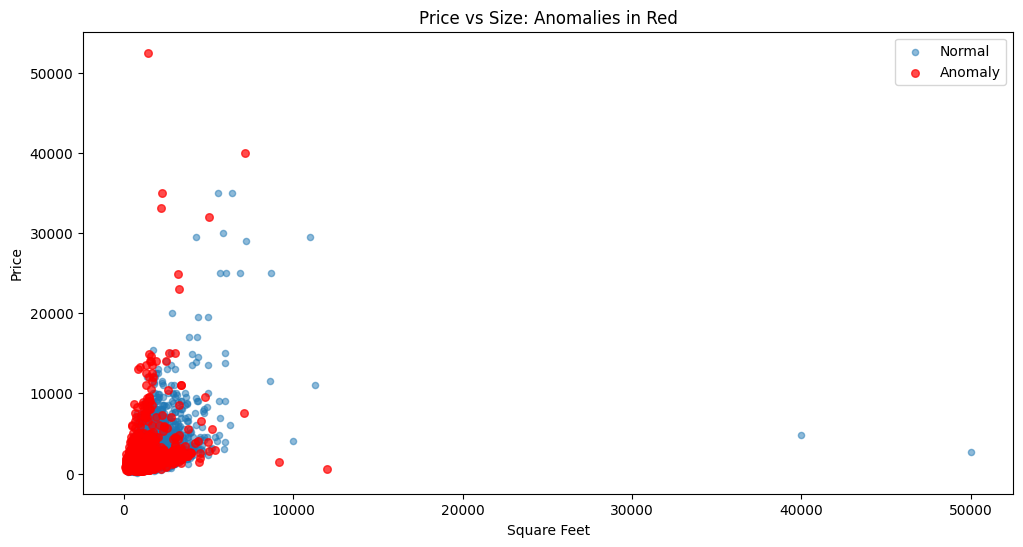

In [157]:
# 5. Quick scatter plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(df[~df['is_price_anomaly']]['square_feet'], 
           df[~df['is_price_anomaly']]['price'], 
           alpha=0.5, label='Normal', s=20)
ax.scatter(df[df['is_price_anomaly']]['square_feet'], 
           df[df['is_price_anomaly']]['price'], 
           alpha=0.7, color='red', label='Anomaly', s=30)
ax.set_xlabel('Square Feet')
ax.set_ylabel('Price')
ax.set_title('Price vs Size: Anomalies in Red')
ax.legend()
plt.show()

In [158]:
# 1. Count total anomalies
print(f"Total anomalies detected: {df['is_price_anomaly'].sum()}")
print(f"Percentage of dataset: {df['is_price_anomaly'].sum() / len(df) * 100:.2f}%")

Total anomalies detected: 3437
Percentage of dataset: 3.45%


In [160]:
# 3. View actual anomalous listings
df[df["is_price_anomaly"]][["cityname", "price", "square_feet", "price_per_sqft", "title"]].head(20)

,cityname,price,square_feet,price_per_sqft,title
31,Austin,1722.0,453,3.801325,Studio apartment 300 E Riverside Dr
52,Tulsa,495.0,360,1.375000,One BR 2613 E Archer St.
55,Providence,2095.0,390,5.371795,Studio apartment 1 Point St
82,Omaha,885.0,468,1.891026,Studio apartment 3618 Farnam St
85,Carlsbad,1795.0,500,3.590000,One BR 350-370 Chinquapin Avenue
99,Austin,1729.0,448,3.859375,Studio apartment 311 Bowie
117,Gainesville,1160.0,338,3.431953,Studio apartment 1258 Nw 3rd Ave
118,College Station,1225.0,450,2.722222,One BR 717 University Dr
128,Greeley,1025.0,500,2.050000,Studio apartment 2101 22nd Avenue
139,New Bedford,1495.0,825,1.812121,One BR 42 West Hill Road


### 2. Over-Accommodation Metric

In [ ]:
# 1. Count amenities
df["amenity_count"] = df["amenities"].fillna("").str.split(",").apply(len)
# Remove rows where amenities was empty (they'd have count 1 for empty string)
df.loc[df["amenities"].isna(), "amenity_count"] = 0

# Quick check
print(df["amenity_count"].describe())
print(df[df["amenity_count"] > 0][["amenities", "amenity_count"]].head())

count    99492.000000
mean         3.663199
std          3.302822
min          0.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         18.000000
Name: amenity_count, dtype: float64
                                         amenities  amenity_count
21  Fireplace,Gym,Parking,Pool,Storage,Wood Floors              6
22                                      Gated,Pool              2
23                         Dishwasher,Parking,Pool              3
24                         Dishwasher,Parking,Pool              3
25                                        Gym,Pool              2


In [168]:
# 2. Pets Allowed Count
df["pets_allowed_count"] = df["pets_allowed"].fillna("").str.split(",").apply(len)
df.loc[df["pets_allowed"].isna(), "pets_allowed_count"] = 0

# Quick check
print(df["pets_allowed_count"].describe())
print(df[df["pets_allowed_count"] > 0][["pets_allowed", "pets_allowed_count"]].head())

count    99492.000000
mean         0.765559
std          0.961913
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max          3.000000
Name: pets_allowed_count, dtype: float64
  pets_allowed  pets_allowed_count
0         Cats                   1
1    Cats,Dogs                   2
3    Cats,Dogs                   2
4    Cats,Dogs                   2
5    Cats,Dogs                   2
